# GANs and Diffusion Models

The [previous page](generativemodels.ipynb) framed generative modeling as
predicting distributions of outputs. This page introduces the first two of
three state-of-the-art generative architectures, the **generative adversarial
network (GAN)** and the **diffusion model**, and surveys how they are used in
climate and environmental science. We will:

- See how generative models **learn the underlying distribution** of the data
  rather than a decision boundary.
- Understand the **generator vs. discriminator** game that trains a GAN.
- Understand **forward noising and learned denoising** in diffusion models.
- Survey applications: **downscaling**, **anomaly detection**, and **ensemble
  weather forecasting**.

## Learning the distribution, not the boundary

Think back to classification. A *discriminative* model looks at examples of,
say, dogs and cats and learns where to put the **decision boundary** between
the classes: on this side, probably a dog; on that side, probably a cat. A
*generative* model asks a harder question: what is the **underlying
distribution** that dog examples are drawn from, and likewise for cats? If we
learn that distribution, we can do more than classify. We can **draw new
samples** from it: completely new images of dogs that were never in the
training set but are consistent with what the model learned a dog to be.

The toy example below makes the contrast concrete with two point clouds in two
dimensions. The discriminative model (a logistic regression) only learns the
line that separates them. The generative model fits a Gaussian distribution to
each class, and can then generate brand new points from those fits.

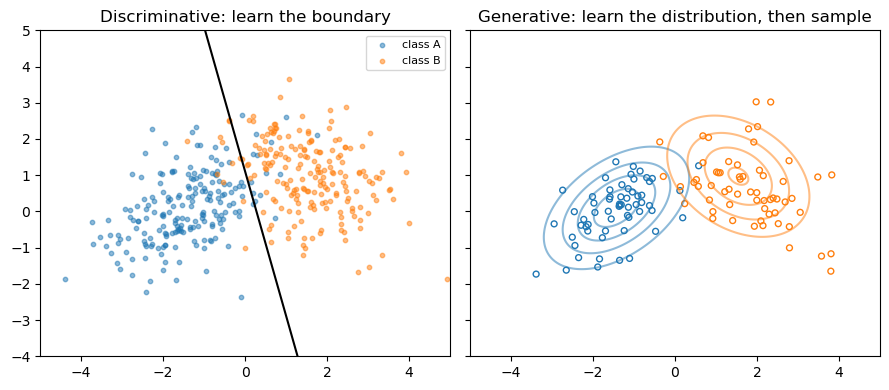

fraction of newly generated points the classifier assigns to the intended class: 0.97


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)

n = 200
Xa = rng.multivariate_normal([-1.5, 0.0], [[1.0, 0.5], [0.5, 1.0]], n)
Xb = rng.multivariate_normal([1.5, 1.0], [[1.0, -0.3], [-0.3, 1.0]], n)
X = np.vstack([Xa, Xb])
y = np.r_[np.zeros(n), np.ones(n)]

clf = LogisticRegression().fit(X, y)

def gauss_pdf(pts, mu, cov):
    "evaluate a 2-D Gaussian density at an array of points"
    d = pts - mu
    inv = np.linalg.inv(cov)
    z = np.einsum("ni,ij,nj->n", d, inv, d)
    return np.exp(-0.5 * z) / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

gx, gy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 5, 200))
grid = np.column_stack([gx.ravel(), gy.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

# left: the discriminative view
p = clf.predict_proba(grid)[:, 1].reshape(gx.shape)
axes[0].contour(gx, gy, p, levels=[0.5], colors="k")
axes[0].scatter(*Xa.T, s=10, alpha=0.5, label="class A")
axes[0].scatter(*Xb.T, s=10, alpha=0.5, label="class B")
axes[0].set_title("Discriminative: learn the boundary")
axes[0].legend(fontsize=8)

# right: the generative view: fit a Gaussian per class, then sample from it
new_pts = []
for Xc, color in [(Xa, "tab:blue"), (Xb, "tab:orange")]:
    mu, cov = Xc.mean(axis=0), np.cov(Xc.T)
    dens = gauss_pdf(grid, mu, cov).reshape(gx.shape)
    axes[1].contour(gx, gy, dens, levels=4, colors=color, alpha=0.5)
    fresh = rng.multivariate_normal(mu, cov, 60)
    new_pts.append(fresh)
    axes[1].scatter(*fresh.T, s=18, facecolors="none", edgecolors=color)
axes[1].set_title("Generative: learn the distribution, then sample")
plt.tight_layout(); plt.show()

gen = np.vstack(new_pts)
gen_labels = np.r_[np.zeros(60), np.ones(60)]
agree = (clf.predict(gen) == gen_labels).mean()
print(f"fraction of newly generated points the classifier assigns "
      f"to the intended class: {agree:.2f}")

On the left, everything the model knows is one curve. On the right, the model
has an explicit density for each class, and the open circles are **new samples
that never existed in the training data**. The printed check confirms the two
views are consistent: nearly all generated points fall on the correct side of
the discriminative boundary. Real data are far too complex for a single
Gaussian per class, of course. The architectures below exist to learn *much*
more flexible distributions, but the goal is exactly the one in the right
panel.

## 1) Generative adversarial networks

A **GAN** trains two networks against each other:

- The **generator** receives a vector of random noise and turns it into a fake
  sample (an image, a rain field, ...).
- The **discriminator** receives either a fake sample from the generator or a
  real one from the training set, and must decide which it is.

Both are trained *simultaneously*: the generator is optimized to fool the
discriminator, and the discriminator to catch the generator. As the
discriminator gets sharper, the generator is forced to make its fakes ever
more realistic, and by the end it has effectively learned the underlying data
distribution. Trained on photographs of faces, GANs produce the famous "deep
fake" portraits of people who do not exist; trained on birds or clothing, they
generate new, unseen but plausible birds and shirts.

GANs have become somewhat less popular in the last few years, displaced by the
diffusion models below, partly because balancing two competing networks makes
them notoriously tricky to train. But they remain fast at inference and widely
used.

### Application: downscaling

Downscaling, going from low resolution to high resolution, is the motivating
problem from the [previous page](generativemodels.ipynb), and a natural GAN
application. RainScaleGAN (Iotti et al. 2025) is a *conditional* GAN for
rainfall downscaling: the generator receives the coarse resolution rainfall
field as conditioning information along with the noise vector, and produces a
plausible high resolution field; the discriminator sees either that generated
field or the true high resolution field. Because the generator also takes
noise, one coarse field can be downscaled many times to get an **ensemble** of
plausible fine scale rainfall fields, exactly the uncertainty-aware output we
argued for earlier.

### Application: anomaly detection

A generative model knows what *normal* data look like, so it can flag what it
cannot explain. Li et al. (2023) used GANs for real time monitoring of water
distribution systems: trained on multi-parameter, multi-site water quality
records, the model detects contamination events as anomalous signals that
depart from the learned distribution, enabling automated monitoring without
hand-labeled examples of every possible contamination.

## 2) Diffusion models

**Diffusion probabilistic models** have largely taken over from GANs as the
state of the art. The idea has two halves:

- **Forward process**: take a training sample and *gradually add noise* to it,
  step by step, until nothing but noise remains.
- **Reverse process**: train a network to *undo one step of noising*. Starting
  from pure noise and applying the learned denoiser step by step then
  generates a brand new sample from the data distribution.

Compared to GANs, diffusion models are **easier to train** (one network, no
adversarial balancing act) and generally produce better samples. Their
principle is also rooted in ideas from statistical physics, which gives them a
more physically grounded interpretation. The price is **slow inference**: a
sample requires many denoising steps rather than one forward pass, and much
current research aims at making both training and sampling faster.

The forward half needs no training at all; here it is on a toy two moons
dataset.

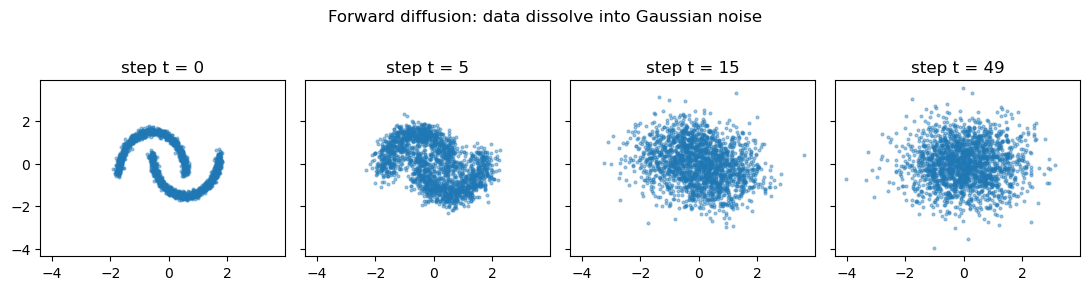

In [2]:
from sklearn.datasets import make_moons

Xm, _ = make_moons(n_samples=2000, noise=0.05, random_state=0)
Xm = (Xm - Xm.mean(axis=0)) / Xm.std(axis=0)

T = 50
betas = np.linspace(1e-4, 0.25, T)          # noise added at each step
alphas = 1 - betas
abar = np.cumprod(alphas)                    # how much signal survives to step t

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), sharex=True, sharey=True)
for ax, t in zip(axes, [0, 5, 15, T - 1]):
    eps = rng.standard_normal(Xm.shape)
    xt = np.sqrt(abar[t]) * Xm + np.sqrt(1 - abar[t]) * eps
    ax.scatter(*xt.T, s=4, alpha=0.4)
    ax.set_title(f"step t = {t}")
fig.suptitle("Forward diffusion: data dissolve into Gaussian noise", y=1.02)
plt.tight_layout(); plt.show()

By the last step the two moons are gone: the points are indistinguishable from
a standard Gaussian. Generation runs this movie backwards. For that we need
the trained denoiser: a network that, given a noisy sample and the step number
$t$, predicts the noise that was added. We can build a miniature version with
the tools we already have: an `MLPRegressor` taking $(x_1, x_2, t)$ as input
and predicting the two components of the noise. Real diffusion models use deep
architectures (typically U-Nets) and hundreds of steps, but the training loop
is the same idea. While sampling we save snapshots along the way, so we can
watch the reverse process mirror the forward one.

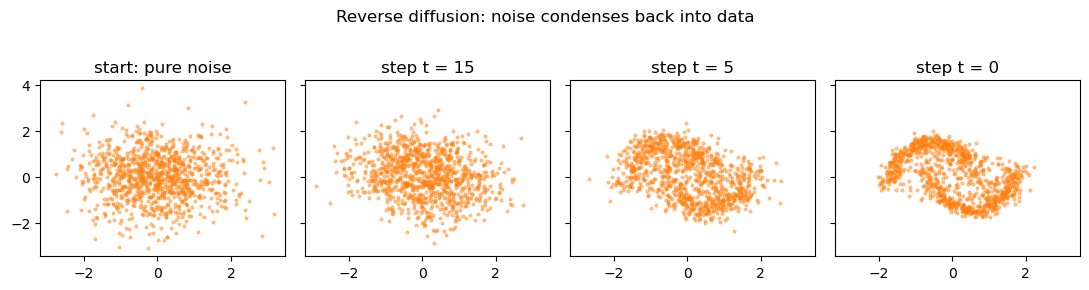

In [3]:
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import NearestNeighbors

# training set: (noisy point, t) -> the noise that was added
reps = 20
idx = rng.integers(0, len(Xm), len(Xm) * reps)
ts = rng.integers(0, T, len(idx))
eps = rng.standard_normal((len(idx), 2))
xt = (np.sqrt(abar[ts])[:, None] * Xm[idx]
      + np.sqrt(1 - abar[ts])[:, None] * eps)
feats = np.column_stack([xt, ts / T])

denoiser = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=200,
                        early_stopping=True, n_iter_no_change=5,
                        random_state=0).fit(feats, eps)

# reverse process: start from pure noise, denoise step by step
n_gen = 1000
x = rng.standard_normal((n_gen, 2))
snapshots = {T: x.copy()}                  # the starting pure noise
for t in reversed(range(T)):
    eps_hat = denoiser.predict(np.column_stack([x, np.full(n_gen, t / T)]))
    x = (x - betas[t] / np.sqrt(1 - abar[t]) * eps_hat) / np.sqrt(alphas[t])
    if t > 0:
        x = x + np.sqrt(betas[t]) * rng.standard_normal((n_gen, 2))
    if t in (15, 5, 0):
        snapshots[t] = x.copy()

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), sharex=True, sharey=True)
for ax, t in zip(axes, [T, 15, 5, 0]):
    ax.scatter(*snapshots[t].T, s=4, alpha=0.4, color="tab:orange")
    ax.set_title("start: pure noise" if t == T else f"step t = {t}")
fig.suptitle("Reverse diffusion: noise condenses back into data", y=1.02)
plt.tight_layout(); plt.show()

Read against the forward figure above, this is the same movie in reverse: the
starting panel is indistinguishable from the forward process's final one, at
step $t = 15$ the cloud is still nearly formless, by $t = 5$ the two crescents
have emerged from the blur, and the last five steps only sharpen them. Each
panel is the same 1000 points partway through denoising. Comparing the
finished samples against the real data:

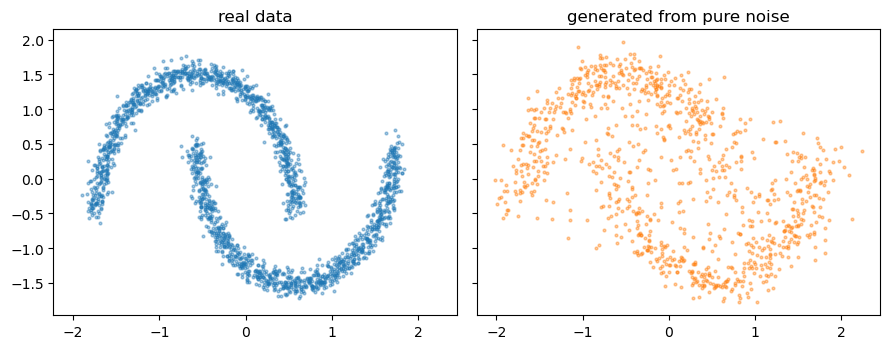

fraction of generated points within 0.25 of a real data point: 0.90


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True, sharey=True)
axes[0].scatter(*Xm.T, s=4, alpha=0.4)
axes[0].set_title("real data")
axes[1].scatter(*x.T, s=4, alpha=0.4, color="tab:orange")
axes[1].set_title("generated from pure noise")
plt.tight_layout(); plt.show()

d, _ = NearestNeighbors(n_neighbors=1).fit(Xm).kneighbors(x)
print(f"fraction of generated points within 0.25 of a real data point: "
      f"{(d < 0.25).mean():.2f}")

Starting from 1000 points of pure Gaussian noise, fifty passes through a small
denoising network recover the two moons. The printed check quantifies it:
about nine in ten generated points land within 0.25 of the data manifold, and
none of them are copies of training points. This is the entire mechanism
behind modern image generators, at toy scale.

## Applications of diffusion models

**Ensemble weather forecasting, without the ensemble.** Weather forecasts are
more accurate as ensembles: run the model many times from slightly different
states and average, as we saw with the spread vs. skill plot on the [previous
page](generativemodels.ipynb). But every extra member costs a full model run.
Recent work at Google
([SEEDS](https://www.science.org/doi/10.1126/sciadv.adk4489), Li et al. 2024)
uses diffusion models for *generative emulation* of
forecast ensembles: train on existing ensembles, then, given one or two
forecasts, generate the rest of the ensemble by sampling instead of rerunning
the physics. The generated ensembles reproduce the statistics of the true
ensemble at a small fraction of the cost. Google DeepMind's
[GenCast](https://www.nature.com/articles/s41586-024-08252-9) (see also the
[blog post](https://deepmind.google/blog/gencast-predicts-weather-and-the-risks-of-extreme-conditions-with-sota-accuracy/))
goes further: the weather model itself is a diffusion model, generating a full
ensemble of possible future weather trajectories directly and predicting
extreme conditions with state of the art accuracy.

**Cyclone track prediction.** A related [Google DeepMind
effort](https://deepmind.google/blog/how-were-supporting-better-tropical-cyclone-prediction-with-ai/)
applies diffusion based ensembles to tropical cyclone tracks. Early in the forecast the
generated tracks cluster tightly; further out they diverge, tracing the
familiar cone of uncertainty. Across many storms the diffusion ensembles
tracked the true cyclone paths better than the deterministic baseline, and the
spread of tracks communicates the forecast's confidence directly.

## Summary

- Generative models learn the **data distribution** and can draw new samples
  from it; discriminative models only learn decision boundaries.
- **GANs** train a generator against a discriminator; powerful but tricky to
  balance. Conditional GANs downscale rainfall; the learned notion of "normal"
  supports anomaly detection.
- **Diffusion models** noise data forward and learn to denoise backward;
  easier to train, currently the state of the art, but slower at inference.
- In climate science these models downscale rainfall, flag anomalies, and
  produce cheap forecast ensembles and cyclone track cones.

The [next page](vaes.ipynb) covers the third architecture, the variational
autoencoder, and what its latent spaces offer scientific analysis.